In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

--- Customer Insights Summary ---
Total Profiles Analyzed: 200
High-Value Target Base: 70 customers
Low-Engagement Warning Base: 40 customers

--- Segment Averages ---
         Spending  Visits    Age
Segment                         
Low        1209.0    9.00  42.98
Medium     7744.0   10.21  44.46
High      12413.0   10.38  42.56


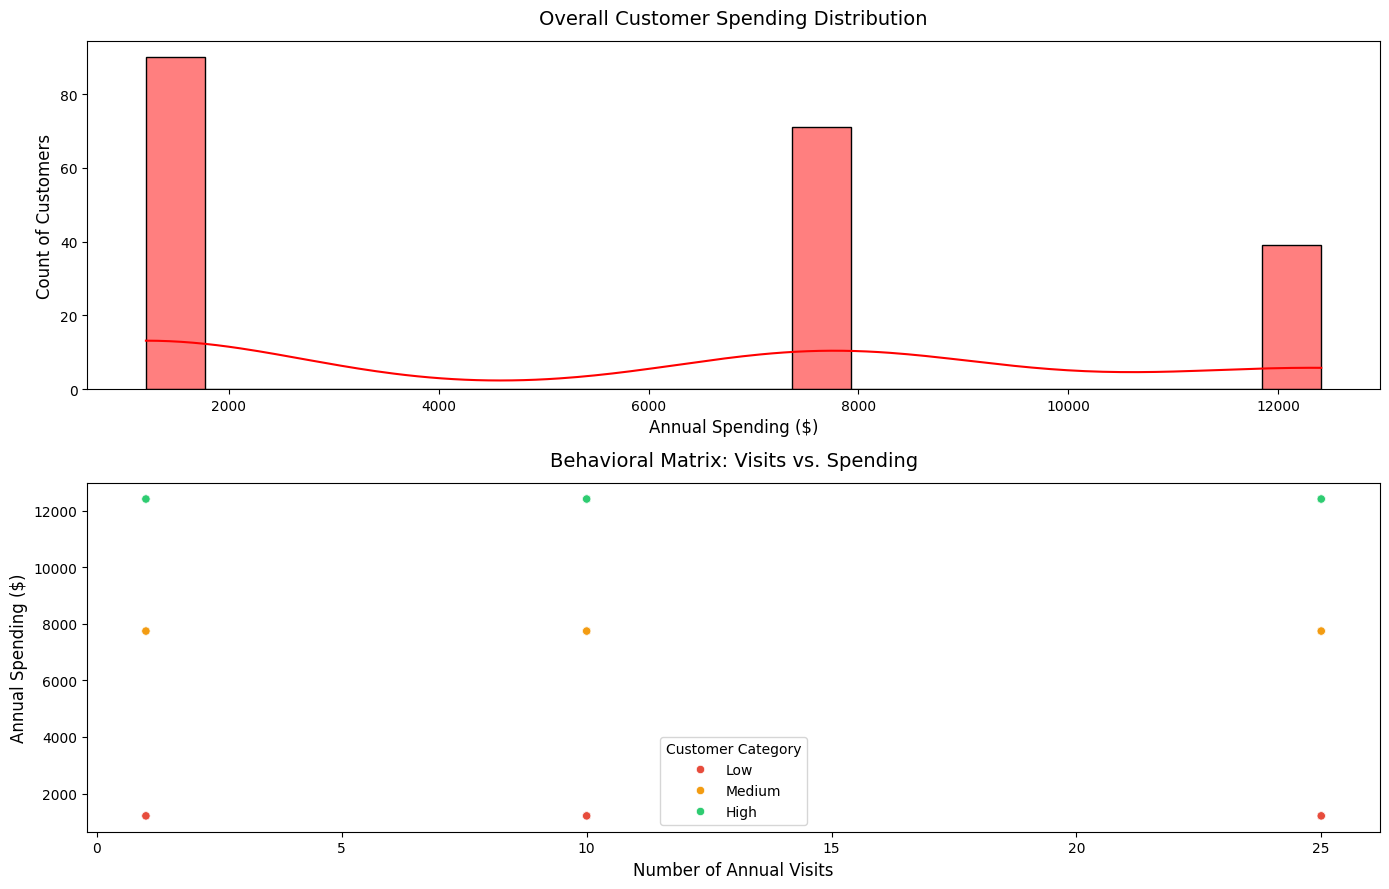

In [32]:
np.random.seed(42)
n_customers = 200

data = {
    "CustomerID": range(1001, 1001 + n_customers),
    "Age": np.random.randint(18, 70, size=n_customers),
    "Spending": np.random.choice(
        [
            np.random.randint(500, 3000),
            np.random.randint(3000, 8000),
            np.random.randint(8000, 20000),
        ],
        size=n_customers,
        p=[0.5, 0.3, 0.2],
    ),
    "Visits": np.random.choice(
        [
            np.random.randint(1, 5),
            np.random.randint(5, 12),
            np.random.randint(12, 30),
        ],
        size=n_customers,
        p=[0.4, 0.4, 0.2],
    ),
}

df = pd.DataFrame(data)

# GROUP & SEGMENT CUSTOMERS (BONUS TASK)

bins = [0, 4000, 10000, df["Spending"].max() + 1]
labels = ["Low", "Medium", "High"]
df["Segment"] = pd.cut(df["Spending"], bins=bins, labels=labels)

# 2. IDENTIFY SPECIFIC BEHAVIORAL GROUPS

high_value_cutoff_spend = df["Spending"].quantile(0.75)
high_value_cutoff_visits = df["Visits"].quantile(0.75)

high_value_df = df[
    (df["Spending"] >= high_value_cutoff_spend)
    & (df["Visits"] >= high_value_cutoff_visits)
]

low_eng_cutoff_spend = df["Spending"].quantile(0.35)
low_eng_cutoff_visits = df["Visits"].quantile(0.35)

low_engagement_df = df[
    (df["Spending"] <= low_eng_cutoff_spend)
    & (df["Visits"] <= low_eng_cutoff_visits)
]

print(f"--- Customer Insights Summary ---")
print(f"Total Profiles Analyzed: {len(df)}")
print(f"High-Value Target Base: {len(high_value_df)} customers")
print(f"Low-Engagement Warning Base: {len(low_engagement_df)} customers\n")

# Displaying segment metrics
segment_summary = (
    df.groupby("Segment", observed=False)[["Spending", "Visits", "Age"]]
    .mean()
    .round(2)
)
print("--- Segment Averages ---")
print(segment_summary)

# VISUALIZATION

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# bar1 - Spending by Segment
sns.histplot(
    data=df, x="Spending", kde=True, color="#ff0000", bins=20, ax=axes[0]
)
axes[0].set_title("Overall Customer Spending Distribution", fontsize=14, pad=12)
axes[0].set_xlabel("Annual Spending ($)", fontsize=12)
axes[0].set_ylabel("Count of Customers", fontsize=12)


#bar 2 : coustomer category by visits
sns.scatterplot(
    data=df, x="Visits", y="Spending", hue="Segment", palette={"Low": "#e74c3c", "Medium": "#f39c12", "High": "#2ecc71"},ax=axes[1],
)
axes[1].set_title("Behavioral Matrix: Visits vs. Spending", fontsize=14, pad=12)
axes[1].set_xlabel("Number of Annual Visits", fontsize=12)
axes[1].set_ylabel("Annual Spending ($)", fontsize=12)
axes[1].legend(title="Customer Category")

plt.tight_layout()
plt.show()